# Gold Atom Extraction Pipeline

Commentary to structured JSON: atomic facts, variations, alternatives.

**Input:** `data/logical_chess.jsonl`

**Outputs:**
- `data/gold_extractions.jsonl` — structured gold templates
- `data/generated_templates_excluded.jsonl` — entries excluded during extraction

`wp_loss` is computed on the fly from engine analysis during extraction.

---
## Setup & Data Loading

In [17]:
import os
import json
import math
import random
import chess
import chess.engine
import chess.svg
from IPython.display import display, SVG, Markdown
from tqdm.notebook import tqdm
from dotenv import load_dotenv
from dataclasses import dataclass

load_dotenv()

STOCKFISH_PATH = '/opt/homebrew/bin/stockfish'
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'evaluation', 'data')
JSONL_PATH = os.path.join(DATA_DIR, 'logical_chess.jsonl')

K = 0.00368208


def cp_to_winpct(cp):
    """Lichess win% formula: Win% = 50 + 50*tanh(k*cp/2)."""
    return 50 + 50 * math.tanh(K * cp / 2)


def get_engine_analysis(fen, move_uci=None, depth=22, multipv=3):
    """Get Stockfish top lines. If move_uci given and not in top-N, fetch separately."""
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        result = engine.analyse(board, chess.engine.Limit(depth=depth), multipv=multipv)
        lines = []
        for info in result:
            score = info['score'].white()
            pv = info.get('pv', [])
            if pv:
                b = board.copy()
                san_moves = []
                for m in pv[:8]:
                    san_moves.append(b.san(m))
                    b.push(m)
                cp = score.score(mate_score=10000)
                mate = score.mate()
                eval_str = f'M{mate}' if mate is not None else f'{cp/100:+.2f}'
                lines.append({
                    'move_uci': pv[0].uci(), 'move_san': board.san(pv[0]),
                    'eval': eval_str, 'pv_san': ' '.join(san_moves),
                    'cp': cp, 'mate': mate, 'is_top': True,
                })

        if move_uci is not None:
            if not any(l['move_uci'] == move_uci for l in lines):
                move_obj = chess.Move.from_uci(move_uci)
                move_san = board.san(move_obj)
                b2 = board.copy()
                b2.push(move_obj)
                info2 = engine.analyse(b2, chess.engine.Limit(depth=depth))
                sc2 = info2['score'].white()
                cp2 = sc2.score(mate_score=10000)
                mate2 = sc2.mate()
                eval2 = f'M{mate2}' if mate2 is not None else f'{cp2/100:+.2f}'
                pv2 = info2.get('pv', [])
                pv_sans = [move_san]
                b3 = b2.copy()
                for m in pv2[:7]:
                    pv_sans.append(b3.san(m))
                    b3.push(m)
                lines.append({
                    'move_uci': move_uci, 'move_san': move_san,
                    'eval': eval2, 'pv_san': ' '.join(pv_sans),
                    'cp': cp2, 'mate': mate2, 'is_top': False,
                })

    return lines


print(f'Data dir: {DATA_DIR}')
print(f'Stockfish: {STOCKFISH_PATH}')

Data dir: /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data
Stockfish: /opt/homebrew/bin/stockfish


In [18]:
def compute_wp_loss(engine_lines, move_uci, turn):
    """Compute wp_loss from engine lines already fetched by get_engine_analysis().

    Uses the top-1 line as the best move eval and the played move's eval
    (either from top-N or the separately-fetched line) to compute win% loss.

    Returns (wp_loss, best_move_san, is_top_engine_move).
    """
    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    if not top_lines:
        return 0.0, '?', False

    best = top_lines[0]
    best_cp = best['cp']
    best_san = best['move_san']

    # Is the played move the engine's top choice?
    if best['move_uci'] == move_uci:
        return 0.0, best_san, True

    # Find eval for the played move
    played_line = next((l for l in engine_lines if l['move_uci'] == move_uci), None)
    if played_line is None:
        return 0.0, best_san, False

    played_cp = played_line['cp']
    best_wp = cp_to_winpct(best_cp)
    played_wp = cp_to_winpct(played_cp)

    if turn == chess.WHITE:
        wp_loss = best_wp - played_wp
    else:
        wp_loss = played_wp - best_wp

    return round(max(0, wp_loss), 2), best_san, False


print('compute_wp_loss ready.')

compute_wp_loss ready.


In [19]:
DATASET = [json.loads(line) for line in open(JSONL_PATH)]
print(f'Loaded {len(DATASET)} entries from {JSONL_PATH}')

Loaded 1832 entries from /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/logical_chess.jsonl


---
## Gold Extraction — Commentary to Structured JSON

The LLM receives FEN + move + engine lines + **book commentary** and extracts a structured template.

**Template format (include=true):**
```json
{
  "include": true,
  "book_commentary": "<original commentary>",
  "quality": "good | inaccuracy | mistake | blunder",
  "reasoning": ["atomic fact 1", "atomic fact 2"],
  "variation": "19.Bxh7+ Kh8 20.Bg6+ ...",
  "alternative": { "move": "Qxh7+", "reasoning": [...], "variation": "..." }
}
```

**Exclude criteria:**
- Quality/engine conflict (praises move but wp_loss > 10%)
- Doesn't explain why bad move is bad
- Historical anecdotes, biographies, generic philosophy
- Too minimal to extract atoms

### Worked Examples

Hand-crafted gold templates to illustrate the extraction format.

In [20]:
def find_entry(entries, fen, move_uci):
    for e in entries:
        if e['fen'] == fen and e['move_uci'] == move_uci:
            return e
    raise ValueError(f'Entry not found: {fen} {move_uci}')


def show_example(entry, engine_lines, template, is_bad_move=False):
    """Display a complete example with board, annotation, engine, and template."""
    board = chess.Board(entry['fen'])
    move = chess.Move.from_uci(entry['move_uci'])
    move_san = board.san(move)
    turn = 'White' if board.turn == chess.WHITE else 'Black'
    game = entry['metadata'].get('White', '?') + ' \u2013 ' + entry['metadata'].get('Black', '?')
    event = entry['metadata'].get('Event', '?')
    date = entry['metadata'].get('Date', '?')

    arrow_color = '#cc0000' if is_bad_move else '#15781B'
    svg = chess.svg.board(board, arrows=[(move.from_square, move.to_square)],
                          colors={'arrow': arrow_color}, size=350)
    display(SVG(svg))

    best_san = entry.get('best_move_san', '?')
    wp_loss = entry.get('wp_loss', 0)
    is_top = entry.get('is_top_engine_move', False)
    quality = 'Engine best' if is_top else f'Not engine best (best: {best_san}, wp_loss: {wp_loss:.1f}%)'

    display(Markdown(f'**{game}** ({event}, {date}) \u2014 **{turn} plays {move_san}** \u2014 {quality}'))
    display(Markdown(f'**FEN:** `{entry["fen"]}`'))
    display(Markdown(f'### Annotation\n> {entry["annotation"]}'))

    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    played_line = next((l for l in engine_lines if not l.get('is_top', True)), None)
    pv_lines = []
    for i, line in enumerate(top_lines, 1):
        played_tag = ' <- played' if line['move_uci'] == entry['move_uci'] else ''
        pv_lines.append(f'{i}. **{line["move_san"]}** (eval {line["eval"]}): {line["pv_san"]}{played_tag}')
    if played_line:
        pv_lines.append(f'\n*Played: **{played_line["move_san"]}** ({played_line["eval"]}): '
                         f'{played_line["pv_san"]}* <- played')
    display(Markdown('### Engine (depth 22)\n' + '\n'.join(pv_lines)))
    display(Markdown('### Template\n```\n' + template.strip() + '\n```'))
    display(Markdown('---'))

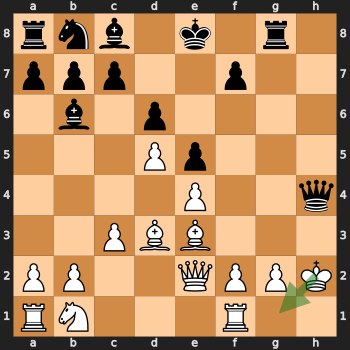

**Liubarski – Soultanbeieff** (Liege, 1928.??.??) — **White plays Kg1** — Engine best

**FEN:** `rnb1k1r1/ppp2p2/1b1p4/3Pp3/4P2q/2PBB3/PP2QPPK/RN3R2 w q - 1 16`

### Annotation
> White’s only move.

### Engine (depth 22)
1. **Kg1** (eval M-7): Kg1 Qh3 Bb5+ c6 Qg4 Rxg4 g3 Bxe3 <- played

### Template
```
{
  "include": true,
  "book_commentary": "White\u2019s only move.",
  "quality": "good",
  "reasoning": [
    "Kg1 is White's only legal king move."
  ]
}
```

---

In [21]:
# Example 1: Kg1 (good, minimal)
entry = find_entry(DATASET,
    'rnb1k1r1/ppp2p2/1b1p4/3Pp3/4P2q/2PBB3/PP2QPPK/RN3R2 w q - 1 16', 'h2g1')
engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])
wp, best_san, is_top = compute_wp_loss(engine_lines, entry['move_uci'], chess.Board(entry['fen']).turn)
entry['wp_loss'] = wp; entry['best_move_san'] = best_san; entry['is_top_engine_move'] = is_top
template = json.dumps({
    "include": True, "book_commentary": entry['annotation'], "quality": "good",
    "reasoning": ["Kg1 is White's only legal king move."]
}, indent=2)
show_example(entry, engine_lines, template)

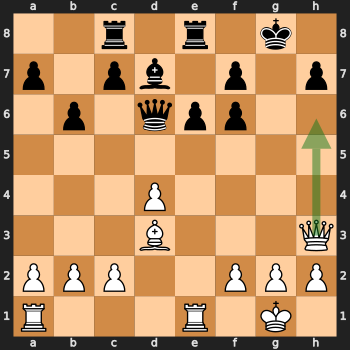

**Tarrasch – Mieses** (Berlin, 1916.??.??) — **White plays Qh6** — Engine best

**FEN:** `2r1r1k1/p1pb1p1p/1p1qpp2/8/3P4/3B3Q/PPP2PPP/R3R1K1 w - - 0 18`

### Annotation
> Holding the king fast! The idea is to keep him from escaping by way of f8 while facing him with deadly threats. The modus operandi after the text-move is 19 Bxh7+! Kh8 20 Bg6+ Kg8 21 Qh7+ Kf8 22 Qxf7#.
If you can play this sort of move (18 Qh6), you are a cut above the average player. Most young players (in a chess sense) have a tendency to try checking the king to death only to find after something like 18 Qxh7+ Kf8 19 Qh8+ Ke7 that the king has escaped and the attack is exhausted. What is worse is that White’s queen and d-pawn are threatened, and that saving both by 20 Qh4 lets Black respond with 20... Rh8 and suddenly White is thrown on the defensive!

### Engine (depth 22)
1. **Qh6** (eval +5.61): Qh6 f5 Re3 f6 Rg3+ Qxg3 hxg3 c5 <- played
2. **Re3** (eval +3.66): Re3 Kf8 Qh4 f5 Rd1 Bc6 Qh6+ Ke7
3. **Qh4** (eval +3.65): Qh4 f5 Re3 Kf8 Rd1 Bc6 Qh6+ Ke7

### Template
```
{
  "include": true,
  "book_commentary": "Holding the king fast! The idea is to keep him from escaping by way of f8 while facing him with deadly threats. The modus operandi after the text-move is 19 Bxh7+! Kh8 20 Bg6+ Kg8 21 Qh7+ Kf8 22 Qxf7#.\nIf you can play this sort of move (18 Qh6), you are a cut above the average player. Most young players (in a chess sense) have a tendency to try checking the king to death only to find after something like 18 Qxh7+ Kf8 19 Qh8+ Ke7 that the king has escaped and the attack is exhausted. What is worse is that White\u2019s queen and d-pawn are threatened, and that saving both by 20 Qh4 lets Black respond with 20... Rh8 and suddenly White is thrown on the defensive!",
  "quality": "good",
  "reasoning": [
    "Qh6 prevents the king from escaping via f8.",
    "The Bd3 aims at h7 along the b1-h7 diagonal.",
    "Sets up a forced mating sequence."
  ],
  "variation": "19.Bxh7+ Kh8 20.Bg6+ Kg8 21.Qh7+ Kf8 22.Qxf7#",
  "alternative": {
    "move": "Qxh7+",
    "reasoning": [
      "After 18.Qxh7+ Kf8 19.Qh8+ Ke7, the king escapes and the attack is exhausted."
    ]
  }
}
```

---

In [22]:
# Example 2: Qh6 (good, rich with variation + alternative)
entry = find_entry(DATASET,
    '2r1r1k1/p1pb1p1p/1p1qpp2/8/3P4/3B3Q/PPP2PPP/R3R1K1 w - - 0 18', 'h3h6')
engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])
wp, best_san, is_top = compute_wp_loss(engine_lines, entry['move_uci'], chess.Board(entry['fen']).turn)
entry['wp_loss'] = wp; entry['best_move_san'] = best_san; entry['is_top_engine_move'] = is_top
template = json.dumps({
    "include": True, "book_commentary": entry['annotation'], "quality": "good",
    "reasoning": [
        "Qh6 prevents the king from escaping via f8.",
        "The Bd3 aims at h7 along the b1-h7 diagonal.",
        "Sets up a forced mating sequence."
    ],
    "variation": "19.Bxh7+ Kh8 20.Bg6+ Kg8 21.Qh7+ Kf8 22.Qxf7#",
    "alternative": {
        "move": "Qxh7+",
        "reasoning": [
            "After 18.Qxh7+ Kf8 19.Qh8+ Ke7, the king escapes and the attack is exhausted."
        ]
    }
}, indent=2)
show_example(entry, engine_lines, template)

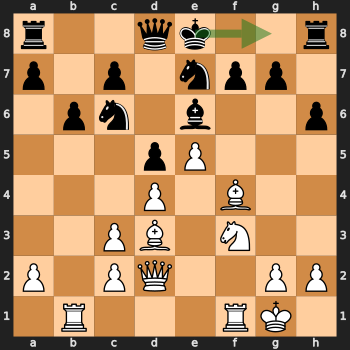

**Blackburne – Blanchard** (London, 1891.??.??) — **Black plays O-O** — Not engine best (best: Qd7, wp_loss: 25.4%)

**FEN:** `r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12`

### Annotation
> Walking right into the teeth of the storm!
Before making a move that suggests itself so readily, Black might have asked himself, “How can I exploit White’s one weakness, the doubled pawns on the c-file?”
He might then have hit upon 12... Na5, with the object of swinging the knight to c4. There it blockades the doubled pawn, interferes with the free movement of White’s pieces, and in general sticks like a bone in the throat. White could capture the knight, but then he parts with one of his valuable bishops, and as a result of the exchange his pawn position would be inferior to Black’s. Finally, Black could then anchor one of his pieces to great effect on d5, a square from which it could never be evicted by pawns.

### Engine (depth 22)
1. **Qd7** (eval +1.05): Qd7 Qf2 Bf5 Ne1 Nd8 Bc1 Be4 Qg3
2. **Na5** (eval +1.20): Na5 Bb5+ c6 Bd3 Ng6 Bg3 Nc4 Qf2
3. **Bf5** (eval +1.37): Bf5 Bxf5 Nxf5 Rbe1 Qd7 Qd3 O-O-O Nd2

*Played: **O-O** (+4.70): O-O Bxh6 Ng6 h4 Nxh4 Bg5 Nxf3+ Rxf3* <- played

### Template
```
{
  "include": true,
  "book_commentary": "Walking right into the teeth of the storm!\nBefore making a move that suggests itself so readily, Black might have asked himself, \u201cHow can I exploit White\u2019s one weakness, the doubled pawns on the c-file?\u201d\nHe might then have hit upon 12... Na5, with the object of swinging the knight to c4. There it blockades the doubled pawn, interferes with the free movement of White\u2019s pieces, and in general sticks like a bone in the throat. White could capture the knight, but then he parts with one of his valuable bishops, and as a result of the exchange his pawn position would be inferior to Black\u2019s. Finally, Black could then anchor one of his pieces to great effect on d5, a square from which it could never be evicted by pawns.",
  "quality": "mistake",
  "reasoning": [
    "Castles into White's prepared kingside attack.",
    "White's one weakness is the doubled c-pawns \u2014 Black should be exploiting that instead."
  ],
  "alternative": {
    "move": "Na5",
    "reasoning": [
      "Reroutes the knight toward c4, where it blockades the doubled c-pawn.",
      "Interferes with the free movement of White's pieces.",
      "If White captures (Bxc4 dxc4), White's pawn structure becomes inferior.",
      "Black can anchor a piece on d5, which cannot be evicted by pawns."
    ]
  }
}
```

---

In [23]:
# Example 3: O-O (mistake with alternative treatment)
entry = find_entry(DATASET,
    'r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12', 'e8g8')
engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])
wp, best_san, is_top = compute_wp_loss(engine_lines, entry['move_uci'], chess.Board(entry['fen']).turn)
entry['wp_loss'] = wp; entry['best_move_san'] = best_san; entry['is_top_engine_move'] = is_top
template = json.dumps({
    "include": True, "book_commentary": entry['annotation'], "quality": "mistake",
    "reasoning": [
        "Castles into White's prepared kingside attack.",
        "White's one weakness is the doubled c-pawns \u2014 Black should be exploiting that instead."
    ],
    "alternative": {
        "move": "Na5",
        "reasoning": [
            "Reroutes the knight toward c4, where it blockades the doubled c-pawn.",
            "Interferes with the free movement of White's pieces.",
            "If White captures (Bxc4 dxc4), White's pawn structure becomes inferior.",
            "Black can anchor a piece on d5, which cannot be evicted by pawns."
        ]
    }
}, indent=2)
show_example(entry, engine_lines, template, is_bad_move=True)

---
### Extraction System Prompt & Few-Shot Demos

In [24]:
SYSTEM_PROMPT = """\
You are extracting structured move explanations from chess commentary.

You will receive: a FEN, the move played, engine analysis, and commentary
for that move. Your job is to EXTRACT and STRUCTURE the commentary into a
JSON object.

Output ONLY valid JSON. No preamble, no markdown fences, no explanation.

When include=true, output:
{
  "include": true,
  "book_commentary": "<the full original commentary>",
  "quality": "good | inaccuracy | mistake | blunder",
  "reasoning": ["atomic fact 1", "atomic fact 2"],
  "variation": "19.Bxh7+ Kh8 20.Bg6+ ...",
  "alternative": {
    "move": "Qxh7+",
    "reasoning": ["why it's worse/better"],
    "variation": "18.Qxh7+ Kf8 ..."
  }
}

When include=false, output ONLY:
{
  "include": false,
  "exclude_reason": "short explanation",
  "book_commentary": "<the full original commentary>"
}

Quality classification (use the engine data provided):
  good       -> wp_loss <= 10%
  inaccuracy -> wp_loss > 10%
  mistake    -> wp_loss > 20%
  blunder    -> wp_loss > 30%

CRITICAL RULES:

1. EXTRACTION ONLY. Extract information present in the commentary.
   Do NOT invent strategic claims the author did not make.
   Do NOT add alternative moves not discussed in the commentary.

2. Board-verifiable enrichment is OK: piece locations, whether a move
   gives check, whether a square is controlled. Use tools to verify.

3. CONTEXTUAL ATOMS. Each reasoning atom must be self-contained with full
   positional context. If an atom references a position after a sequence of
   moves, include the FULL preceding move sequence so it can be verified
   independently.

   EXAMPLE — given this text:
   "Nxd7 removes one of the defenders of the knight on f6, aiming to
   undermine Black's kingside defenses. After the expected Nh5, White can
   capture the bishop on g6, opening up Black's king to further attacks."

   BAD atoms (later atoms lose context):
   - "Nxd7 removes one of the defenders of the knight on f6."
   - "After Nh5, White can capture the bishop on g6."  <- Nh5 from where?
   - "Capturing the bishop on g6 opens up Black's king."  <- after what?

   GOOD atoms (each carries full move sequence from root):
   - "Nxd7 removes one of the defenders of the knight on f6."
   - "After Nxd7 Nh5, White can capture the bishop on g6."
   - "After Nxd7 Nh5, capturing on g6 opens up Black's king to attack."

4. Group logically connected setup+consequence into a SINGLE atom.

5. Name squares, pieces, and diagonals concretely.

6. INCLUDE/EXCLUDE. Set \"include\": false when:
   - Commentary praises a move but engine shows wp_loss > 10%
   - Commentary doesn't explain WHY a bad move is bad
   - Historical anecdotes, biographies, no move-specific analysis
   - Generic chess philosophy not applied to this position
   - Raw notation only, or too minimal to extract atoms

7. NEVER include generic philosophical statements as atoms.

8. Depth matches the commentary's richness, NOT an imposed judgment.

9. For inaccuracy/mistake/blunder: reasoning = why this move fails;
   alternative = the better move (from commentary only).

Available tools (verify board claims, NOT generate new content):
  get_attacks, get_attackers, get_legal_moves, is_pinned, is_check,
  try_variation, compare_moves, make_move, get_piece_at, get_engine_eval
"""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 3287 chars


In [25]:
# ── Hardcoded demo data (from review_demo.jsonl) ────────────────────────
# Engine lines pre-stored so demos are deterministic (no Stockfish needed).

DEMO_DATA = [
    # Demo 1: Qe5 — good, tactical (pin + attack + rejected alternative)
    {
        'fen': 'rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8',
        'move_uci': 'a5e5',
        'annotation': (
            'Black\u2019s response pins the e2-bishop and attacks the unprotected '
            'd4-knight. Black rejects 8... Bxe2 as the recapture by 9 Qxe2+ '
            'gains another tempo for White.'
        ),
        'wp_loss': 0.0,
        'engine_lines': [
            {'move_uci': 'a5e5', 'move_san': 'Qe5', 'eval': '+1.18',
             'pv_san': 'Qe5 a3 Bxe2 Qxe2 Qxe2+ Kxe2 Bxc3 Bxc3',
             'cp': 118, 'mate': None, 'is_top': True},
            {'move_uci': 'a5c5', 'move_san': 'Qc5', 'eval': '+2.81',
             'pv_san': 'Qc5 Bxg4 Qxd4 Qe2+ Ne7 O-O-O O-O Bg5',
             'cp': 281, 'mate': None, 'is_top': True},
            {'move_uci': 'g4d7', 'move_san': 'Bd7', 'eval': '+3.16',
             'pv_san': 'Bd7 a3 Bxc3 Bxc3 Qb6 Bc4 Ne7 Qh5',
             'cp': 316, 'mate': None, 'is_top': True},
        ],
    },
    # Demo 2: Bxd4 — good, variation with mating attack
    {
        'fen': 'r4rk1/pp1q1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 w - - 0 19',
        'move_uci': 'b2d4',
        'annotation': (
            'White regains the pawn, and his bishop now attacks in two directions. '
            'On the one hand, it threatens to take the a-pawn, on the other it aims '
            'at checkmate by... Bxf6 gxf6 21 Rg4+ Kh8 22 Qh6 Rg8 23 Qxf6+ and '
            'mate next move.'
        ),
        'wp_loss': 0.0,
        'engine_lines': [
            {'move_uci': 'b2d4', 'move_san': 'Bxd4', 'eval': '+0.52',
             'pv_san': 'Bxd4 Bxd4 Rxd4 Qe7 Rfd1 Rfd8 g3 b6',
             'cp': 52, 'mate': None, 'is_top': True},
            {'move_uci': 'e3d3', 'move_san': 'Qd3', 'eval': '-1.66',
             'pv_san': 'Qd3 Rfd8 Bc1 Rac8 h4 Rc5 a4 h6',
             'cp': -166, 'mate': None, 'is_top': True},
            {'move_uci': 'e3f3', 'move_san': 'Qf3', 'eval': '-1.76',
             'pv_san': 'Qf3 Rfe8 Rfe1 e5 g4 Qc6 Qd3 h6',
             'cp': -176, 'mate': None, 'is_top': True},
        ],
    },
    # Demo 3: O-O — mistake with detailed alternative
    {
        'fen': 'r2qk2r/p1p1npp1/1pn1b2p/3pP3/3P1B2/2PB1N2/P1PQ2PP/1R3RK1 b kq - 1 12',
        'move_uci': 'e8g8',
        'annotation': (
            'Walking right into the teeth of the storm!\n'
            'Before making a move that suggests itself so readily, Black might have '
            'asked himself, \u201cHow can I exploit White\u2019s one weakness, the doubled '
            'pawns on the c-file?\u201d\n'
            'He might then have hit upon 12... Na5, with the object of swinging the '
            'knight to c4. There it blockades the doubled pawn, interferes with the '
            'free movement of White\u2019s pieces, and in general sticks like a bone in '
            'the throat. White could capture the knight, but then he parts with one '
            'of his valuable bishops, and as a result of the exchange his pawn '
            'position would be inferior to Black\u2019s. Finally, Black could then anchor '
            'one of his pieces to great effect on d5, a square from which it could '
            'never be evicted by pawns.'
        ),
        'wp_loss': 24.13,
        'engine_lines': [
            {'move_uci': 'd8d7', 'move_san': 'Qd7', 'eval': '+1.05',
             'pv_san': 'Qd7 Qf2 Bf5 Ne1 Nd8 Bc1 Be4 Qg3',
             'cp': 105, 'mate': None, 'is_top': True},
            {'move_uci': 'c6a5', 'move_san': 'Na5', 'eval': '+1.20',
             'pv_san': 'Na5 Bb5+ c6 Bd3 Ng6 Bg3 Nc4 Qf2',
             'cp': 120, 'mate': None, 'is_top': True},
            {'move_uci': 'e6f5', 'move_san': 'Bf5', 'eval': '+1.37',
             'pv_san': 'Bf5 Bxf5 Nxf5 Rbe1 Qd7 Qd3 O-O-O Nd2',
             'cp': 137, 'mate': None, 'is_top': True},
            {'move_uci': 'e8g8', 'move_san': 'O-O', 'eval': '+4.70',
             'pv_san': 'O-O Bxh6 Ng6 h4 Nxh4 Bg5 Nxf3+ Rxf3',
             'cp': 470, 'mate': None, 'is_top': False},
        ],
    },
]

DEMO_FENS = {d['fen'] for d in DEMO_DATA}

# ── Contextual demo responses ────────────────────────────────────────────
# Each atom carries full move-sequence prefix for independent verification.

_DEMO_RESPONSES = [
    # Demo 1: Qe5 (good, tactical)
    {
        'include': True,
        'quality': 'good',
        'reasoning': [
            'Qe5 pins the bishop on e2 to the king on e1.',
            'Qe5 attacks the unprotected knight on d4.',
            'After 8...Bxe2 9.Qxe2+, White recaptures with check, gaining a tempo \u2014 so Black rejects this line.',
        ],
    },
    # Demo 2: Bxd4 (good, variation with mating attack)
    {
        'include': True,
        'quality': 'good',
        'reasoning': [
            'Bxd4 regains the pawn on d4.',
            'After Bxd4, the bishop threatens to capture the a7-pawn.',
            'After Bxd4, the bishop sets up a mating sequence: Bxf6 gxf6, Rg4+ Kh8, Qh6 Rg8, Qxf6+ and mate next move.',
        ],
        'variation': '20.Bxf6 gxf6 21.Rg4+ Kh8 22.Qh6 Rg8 23.Qxf6+',
    },
    # Demo 3: O-O (mistake with alternative)
    {
        'include': True,
        'quality': 'mistake',
        'reasoning': [
            "O-O castles into White's prepared kingside attack.",
            "White's one weakness is the doubled c-pawns \u2014 Black should exploit this instead of castling.",
        ],
        'alternative': {
            'move': 'Na5',
            'reasoning': [
                'After 12...Na5, the knight reroutes toward c4 to blockade the doubled c-pawn.',
                "After 12...Na5 followed by ...Nc4, the knight interferes with the free movement of White's pieces.",
                "After 12...Na5 ...Nc4, if White captures with Bxc4 dxc4, White's pawn structure becomes inferior to Black's.",
                'After 12...Na5, Black can anchor a piece on d5, a square that cannot be evicted by pawns.',
            ],
        },
    },
]

print(f'Demo data: {len(DEMO_DATA)} positions, {len(DEMO_FENS)} FENs')

Demo data: 3 positions, 3 FENs


In [26]:
def build_user_prompt(entry, engine_lines):
    """Build user prompt for gold extraction: FEN + move + engine + commentary."""
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))

    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    played_line = next((l for l in engine_lines if not l.get('is_top', True)), None)

    pv_text = []
    for i, line in enumerate(top_lines, 1):
        pv_text.append(f"  {i}. {line['move_san']} ({line['eval']}): {line['pv_san']}")

    wp_loss = entry.get('wp_loss', 0)
    if wp_loss > 30:   quality_hint = f" [BLUNDER \u2014 wp_loss: {wp_loss:.1f}%]"
    elif wp_loss > 20: quality_hint = f" [MISTAKE \u2014 wp_loss: {wp_loss:.1f}%]"
    elif wp_loss > 10: quality_hint = f" [INACCURACY \u2014 wp_loss: {wp_loss:.1f}%]"
    else:              quality_hint = f" [wp_loss: {wp_loss:.1f}%]"

    prompt = f"FEN: {entry['fen']}\nMove played: {move_san}{quality_hint}\nEngine top-3:\n" + "\n".join(pv_text) + "\n"
    if played_line:
        prompt += f"Played move eval:\n  {played_line['move_san']} ({played_line['eval']}): {played_line['pv_san']}\n"
    prompt += f'\nCommentary: \"{entry["annotation"]}\"\n'
    return prompt


def postprocess_filter(entry, parsed_json):
    """Post-processing filters that catch what the LLM might miss."""
    wp_loss = entry.get('wp_loss', 0)
    quality = parsed_json.get('quality', 'good')

    if quality == 'good' and wp_loss > 10:
        return False, f"quality/engine conflict: commentary says good but wp_loss={wp_loss:.1f}%"
    if quality in ('inaccuracy', 'mistake', 'blunder') and wp_loss < 2:
        return False, f"quality/engine conflict: commentary says {quality} but wp_loss={wp_loss:.1f}%"
    alt = parsed_json.get('alternative')
    if alt and not alt.get('reasoning'):
        return False, "alternative has no reasoning \u2014 likely not from commentary"
    if parsed_json.get('include', True) and not parsed_json.get('reasoning'):
        return False, "no reasoning atoms extracted"
    return parsed_json.get('include', True), parsed_json.get('exclude_reason')

In [27]:
def build_demos(demo_data, demo_responses):
    """Build few-shot demo messages from hardcoded data + responses."""
    demos = []
    for data, resp in zip(demo_data, demo_responses):
        r = {**resp, 'book_commentary': data['annotation']}
        demos.append({'role': 'user', 'content': build_user_prompt(data, data['engine_lines'])})
        demos.append({'role': 'assistant', 'content': json.dumps(r, indent=2)})
    return demos


DEMOS = build_demos(DEMO_DATA, _DEMO_RESPONSES)

print(f'Demos: {len(DEMOS) // 2} examples')

# Show what goes to the LLM
for i in range(0, len(DEMOS), 2):
    n = i // 2 + 1
    print(f'\n{"="*60}')
    print(f'Demo {n} \u2014 USER:')
    print(DEMOS[i]['content'][:200] + '...')
    print(f'\nDemo {n} \u2014 ASSISTANT:')
    print(DEMOS[i+1]['content'])

Demos: 3 examples

Demo 1 — USER:
FEN: rn2k1nr/ppp2ppp/8/q7/1b1N2b1/2N5/PPPBBPPP/R2QK2R b KQkq - 0 8
Move played: Qe5 [wp_loss: 0.0%]
Engine top-3:
  1. Qe5 (+1.18): Qe5 a3 Bxe2 Qxe2 Qxe2+ Kxe2 Bxc3 Bxc3
  2. Qc5 (+2.81): Qc5 Bxg4 Qxd...

Demo 1 — ASSISTANT:
{
  "include": true,
  "quality": "good",
  "reasoning": [
    "Qe5 pins the bishop on e2 to the king on e1.",
    "Qe5 attacks the unprotected knight on d4.",
    "After 8...Bxe2 9.Qxe2+, White recaptures with check, gaining a tempo \u2014 so Black rejects this line."
  ],
  "book_commentary": "Black\u2019s response pins the e2-bishop and attacks the unprotected d4-knight. Black rejects 8... Bxe2 as the recapture by 9 Qxe2+ gains another tempo for White."
}

Demo 2 — USER:
FEN: r4rk1/pp1q1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 w - - 0 19
Move played: Bxd4 [wp_loss: 0.0%]
Engine top-3:
  1. Bxd4 (+0.52): Bxd4 Bxd4 Rxd4 Qe7 Rfd1 Rfd8 g3 b6
  2. Qd3 (-1.66): Qd3 Rfd8 Bc1 Rac8 ...

Demo 2 — ASSISTANT:
{
  "include": true,
  "quality": "go

---
### Chess Tools & API Abstraction

In [28]:
import json as _json

def tool_get_legal_moves(fen):
    board = chess.Board(fen)
    moves = [board.san(m) for m in board.legal_moves]
    return _json.dumps({"moves": moves, "count": len(moves)})

def tool_get_piece_at(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"square": square, "piece": "empty"})
    color = "white" if p.color == chess.WHITE else "black"
    return _json.dumps({"square": square, "piece": f"{color} {chess.piece_name(p.piece_type)}"})

def tool_get_attacks(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    attacks = sorted([chess.square_name(a) for a in board.attacks(sq)])
    return _json.dumps({"piece": p.symbol(), "square": square, "attacks": attacks})

def tool_get_attackers(fen, square, color):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    c = chess.WHITE if color == "white" else chess.BLACK
    attackers = [[chess.piece_name(board.piece_at(a).piece_type), chess.square_name(a)]
                 for a in board.attackers(c, sq)]
    return _json.dumps({"square": square, "color": color, "attackers": attackers})

def tool_is_pinned(fen, square):
    board = chess.Board(fen)
    sq = chess.parse_square(square)
    p = board.piece_at(sq)
    if p is None:
        return _json.dumps({"error": f"no piece on {square}"})
    pinned = board.is_pinned(p.color, sq)
    result = {"square": square, "pinned": pinned}
    if pinned:
        result["pin_ray"] = str(chess.SquareSet(board.pin(p.color, sq)))
    return _json.dumps(result)

def tool_is_check(fen):
    board = chess.Board(fen)
    in_check = board.is_check()
    result = {"in_check": in_check}
    if in_check:
        result["checkers"] = [chess.square_name(sq) for sq in board.checkers()]
    return _json.dumps(result)

def tool_try_variation(fen, moves):
    board = chess.Board(fen)
    played = []
    for san in moves:
        try:
            move = board.parse_san(san)
            played.append(board.san(move))
            board.push(move)
        except Exception as e:
            return _json.dumps({"legal": False, "error": f"{san}: {str(e)}", "played": played})
    result = {"legal": True, "played": played}
    if board.is_checkmate():
        result["eval"] = "checkmate"
    elif board.is_stalemate():
        result["eval"] = "stalemate"
    else:
        with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
            info = engine.analyse(board, chess.engine.Limit(depth=18))
            sc = info['score'].white()
            mate = sc.mate()
            result["eval"] = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
    return _json.dumps(result)

def tool_get_engine_eval(fen, depth=20):
    board = chess.Board(fen)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        info = engine.analyse(board, chess.engine.Limit(depth=int(depth)))
        sc = info['score'].white()
        pv = info.get('pv', [])
        mate = sc.mate()
        ev = f"M{mate}" if mate is not None else f"{sc.score(mate_score=10000)/100:+.2f}"
        best = board.san(pv[0]) if pv else "?"
    return _json.dumps({"eval": ev, "best_move": best})

def tool_compare_moves(fen, move_a, move_b, depth=20):
    board = chess.Board(fen)
    def wp(cp):
        return 50 + 50 * math.tanh(K * cp / 2)
    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        ba = board.copy(); ba.push(board.parse_san(move_a))
        ia = engine.analyse(ba, chess.engine.Limit(depth=int(depth)))
        sa = ia['score'].white().score(mate_score=10000)
        bb = board.copy(); bb.push(board.parse_san(move_b))
        ib = engine.analyse(bb, chess.engine.Limit(depth=int(depth)))
        sb = ib['score'].white().score(mate_score=10000)
    return _json.dumps({
        "move_a": move_a, "eval_a": f"{sa/100:+.2f}",
        "move_b": move_b, "eval_b": f"{sb/100:+.2f}",
        "wp_diff": round(abs(wp(sa) - wp(sb)), 1)
    })

def tool_make_move(fen, move):
    board = chess.Board(fen)
    m = board.parse_san(move)
    gives_check = board.gives_check(m)
    board.push(m)
    return _json.dumps({"fen": board.fen(), "gives_check": gives_check})


TOOL_FUNCTIONS = {
    "get_legal_moves": tool_get_legal_moves, "get_piece_at": tool_get_piece_at,
    "get_attacks": tool_get_attacks, "get_attackers": tool_get_attackers,
    "is_pinned": tool_is_pinned, "is_check": tool_is_check,
    "try_variation": tool_try_variation, "get_engine_eval": tool_get_engine_eval,
    "compare_moves": tool_compare_moves, "make_move": tool_make_move,
}

def _schema(name, desc, props, required):
    return {"type": "function", "function": {"name": name, "description": desc,
            "parameters": {"type": "object", "properties": props, "required": required}}}

_fen_prop = {"fen": {"type": "string", "description": "FEN of the position"}}
_sq_prop = {"square": {"type": "string", "description": "Square name, e.g. 'd3'"}}

TOOL_SCHEMAS_OPENAI = [
    _schema("get_legal_moves", "Get all legal moves in SAN.", _fen_prop, ["fen"]),
    _schema("get_piece_at", "Get the piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attacks", "Get squares attacked by piece on a square.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("get_attackers", "Get pieces of a color attacking a square.",
            {**_fen_prop, **_sq_prop, "color": {"type": "string", "enum": ["white", "black"]}},
            ["fen", "square", "color"]),
    _schema("is_pinned", "Check if a piece is pinned.", {**_fen_prop, **_sq_prop}, ["fen", "square"]),
    _schema("is_check", "Check if side to move is in check.", _fen_prop, ["fen"]),
    _schema("try_variation", "Try a sequence of SAN moves.",
            {**_fen_prop, "moves": {"type": "array", "items": {"type": "string"}}}, ["fen", "moves"]),
    _schema("get_engine_eval", "Get Stockfish eval + best move.",
            {**_fen_prop, "depth": {"type": "integer"}}, ["fen"]),
    _schema("compare_moves", "Compare eval of two moves.",
            {**_fen_prop, "move_a": {"type": "string"}, "move_b": {"type": "string"},
             "depth": {"type": "integer"}}, ["fen", "move_a", "move_b"]),
    _schema("make_move", "Make a move, return new FEN.",
            {**_fen_prop, "move": {"type": "string"}}, ["fen", "move"]),
]

TOOL_SCHEMAS_ANTHROPIC = [
    {"name": s["function"]["name"], "description": s["function"]["description"],
     "input_schema": s["function"]["parameters"]} for s in TOOL_SCHEMAS_OPENAI
]

def execute_tool(name, arguments):
    fn = TOOL_FUNCTIONS.get(name)
    if fn is None:
        return _json.dumps({"error": f"unknown tool: {name}"})
    try:
        return fn(**arguments)
    except Exception as e:
        return _json.dumps({"error": str(e)})

print(f'Tools defined: {list(TOOL_FUNCTIONS.keys())}')

Tools defined: ['get_legal_moves', 'get_piece_at', 'get_attacks', 'get_attackers', 'is_pinned', 'is_check', 'try_variation', 'get_engine_eval', 'compare_moves', 'make_move']


In [29]:
# ── API Abstraction ───────────────────────────────────────────────────────

@dataclass
class ToolCall:
    id: str
    name: str
    arguments: dict

@dataclass
class LLMResponse:
    text: str
    tool_calls: list


def call_openai(messages, tools=None, model="gpt-4o", temperature=0.3):
    import openai
    client = openai.OpenAI()
    token_key = "max_completion_tokens" if any(m in model for m in ("gpt-4.1", "gpt-5", "o3", "o4")) else "max_tokens"
    kwargs = dict(model=model, messages=messages, temperature=temperature, **{token_key: 2048})
    if tools:
        kwargs["tools"] = tools
        kwargs["tool_choice"] = "auto"
    resp = client.chat.completions.create(**kwargs)
    msg = resp.choices[0].message
    text = msg.content or ""
    tc = []
    if msg.tool_calls:
        for c in msg.tool_calls:
            tc.append(ToolCall(id=c.id, name=c.function.name,
                               arguments=_json.loads(c.function.arguments)))
    return LLMResponse(text=text, tool_calls=tc), msg


def call_anthropic(messages, tools=None, model="claude-sonnet-4-5-20250929",
                   system=None, temperature=0.3):
    import anthropic
    client = anthropic.Anthropic()
    kwargs = dict(model=model, max_tokens=2048, temperature=temperature)
    if system:
        kwargs["system"] = system
    api_messages = [m for m in messages if m["role"] != "system"]
    kwargs["messages"] = api_messages
    if tools:
        kwargs["tools"] = tools
    resp = client.messages.create(**kwargs)
    text = ""
    tc = []
    for block in resp.content:
        if block.type == "text":
            text += block.text
        elif block.type == "tool_use":
            tc.append(ToolCall(id=block.id, name=block.name, arguments=block.input))
    return LLMResponse(text=text, tool_calls=tc), resp


def call_llm(messages, tools=None, provider="openai", model=None, temperature=0.3):
    if provider == "openai":
        return call_openai(messages, tools=tools, model=model or "gpt-5.4", temperature=temperature)
    elif provider == "anthropic":
        m = model or "claude-sonnet-4-5-20250929"
        sys_msg = next((msg["content"] for msg in messages if msg["role"] == "system"), None)
        return call_anthropic(messages, tools=tools, model=m, system=sys_msg, temperature=temperature)
    else:
        raise ValueError(f"Unknown provider: {provider}")


print('API abstraction ready.')

API abstraction ready.


---
### Generation Loop

In [30]:
PROVIDER = "openai"      # "openai" or "anthropic"
MODEL = "gpt-5.4"         # or "claude-sonnet-4-5-20250929"
MAX_TOOL_ROUNDS = 10


def generate_with_tools(entry, engine_lines, provider=PROVIDER, model=MODEL):
    """Generate a structured JSON template with optional tool calls."""
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages.extend(DEMOS)
    messages.append({"role": "user", "content": build_user_prompt(entry, engine_lines)})

    tool_schemas = TOOL_SCHEMAS_OPENAI if provider == "openai" else TOOL_SCHEMAS_ANTHROPIC
    tool_log = []

    for round_num in range(MAX_TOOL_ROUNDS):
        resp, raw = call_llm(messages, tools=tool_schemas, provider=provider,
                             model=model, temperature=0.3)

        if not resp.tool_calls:
            return resp.text.strip(), tool_log

        if provider == "openai":
            messages.append({
                "role": "assistant", "content": resp.text or None,
                "tool_calls": [{"id": tc.id, "type": "function",
                                "function": {"name": tc.name,
                                             "arguments": _json.dumps(tc.arguments)}}
                               for tc in resp.tool_calls],
            })
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                messages.append({"role": "tool", "tool_call_id": tc.id, "content": result})
        elif provider == "anthropic":
            content_blocks = []
            if resp.text:
                content_blocks.append({"type": "text", "text": resp.text})
            for tc in resp.tool_calls:
                content_blocks.append({"type": "tool_use", "id": tc.id,
                                       "name": tc.name, "input": tc.arguments})
            messages.append({"role": "assistant", "content": content_blocks})
            tool_results = []
            for tc in resp.tool_calls:
                result = execute_tool(tc.name, tc.arguments)
                tool_log.append({"tool": tc.name, "args": tc.arguments, "result": result})
                print(f"    tool: {tc.name}({tc.arguments}) -> {result[:80]}")
                tool_results.append({"type": "tool_result", "tool_use_id": tc.id,
                                     "content": result})
            messages.append({"role": "user", "content": tool_results})

    return resp.text.strip() if resp.text else "[max tool rounds reached]", tool_log


def parse_json_output(text):
    """Parse the LLM's JSON output, handling markdown fences."""
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"include": False, "exclude_reason": "JSON parse error", "raw": text}


print('Generation loop ready.')

Generation loop ready.


---
### Candidate Selection

Stratified sampling by quality x game phase x annotation length.

In [31]:
from collections import Counter

def get_move_number(fen):
    return int(fen.split()[-1])

def get_game_phase(move_num):
    if move_num <= 10: return 'opening'
    elif move_num <= 25: return 'middlegame'
    else: return 'endgame'

# For candidate selection we just use annotation length and game phase
# (wp_loss is computed during extraction)
all_entries = []
for e in DATASET:
    if e['fen'] not in DEMO_FENS:
        all_entries.append({
            'entry': e,
            'phase': get_game_phase(get_move_number(e['fen'])),
            'ann_len': len(e['annotation'].split()),
        })

phase_counts = Counter(c['phase'] for c in all_entries)
print(f"Entries (excl demos): {len(all_entries)}")
print("By phase:", dict(phase_counts))

# Sample diverse candidates across phases and annotation lengths
random.seed(42)
candidates = []

for phase in ['opening', 'middlegame', 'endgame']:
    phase_pool = [c for c in all_entries if c['phase'] == phase]
    if phase_pool:
        phase_pool.sort(key=lambda c: c['ann_len'])
        short = [c for c in phase_pool if c['ann_len'] <= 15]
        long = [c for c in phase_pool if c['ann_len'] > 30]
        if short: candidates.append(random.choice(short))
        if long: candidates.append(random.choice(long))
        if not short and not long: candidates.append(random.choice(phase_pool))

# Add a few more random entries for variety
extras = random.sample(all_entries, min(6, len(all_entries)))
candidates.extend(extras)

# Deduplicate
seen_fens = set()
unique_candidates = []
for c in candidates:
    if c['entry']['fen'] not in seen_fens:
        seen_fens.add(c['entry']['fen'])
        unique_candidates.append(c)
candidates = unique_candidates

print(f"\nSelected {len(candidates)} candidates")
print(f"  By phase: {dict(Counter(c['phase'] for c in candidates))}")

Entries (excl demos): 1829
By phase: {'opening': 658, 'middlegame': 775, 'endgame': 396}

Selected 12 candidates
  By phase: {'opening': 4, 'middlegame': 4, 'endgame': 4}


---
### Run Extraction


[1/12] Havasi – Capablanca — a3 (opening)
  [EXCLUDED: too minimal to extract move-specific reasoning] quality=good, wp_loss=0.0%


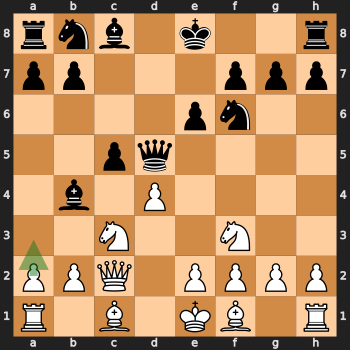

**Havasi – Capablanca** (Budapest, 1929.??.??) — **White plays a3** — Engine best

**FEN:** `rnb1k2r/pp3ppp/4pn2/2pq4/1b1P4/2N2N2/PPQ1PPPP/R1B1KB1R w KQkq - 0 7`

### Annotation
> White has had enough of this tiresome bishop!

### Engine (depth 22)
1. **a3** (eval +0.33): a3 Bxc3+ Qxc3 Nbd7 Be3 b6 dxc5 Nxc5 <- played
2. **Bd2** (eval +0.30): Bd2 Bxc3 Bxc3 Nc6 dxc5 Qxc5 Rc1 O-O
3. **dxc5** (eval +0.16): dxc5 Qxc5 g3 Nc6 Be3 Qa5 Bd2 e5

### Template
```
{
  "include": false,
  "exclude_reason": "too minimal to extract move-specific reasoning",
  "book_commentary": "White has had enough of this tiresome bishop!"
}
```

---


[2/12] Tarrasch – Mieses — Nxe4 (opening)
  [INCLUDED] quality=good, wp_loss=0.0%


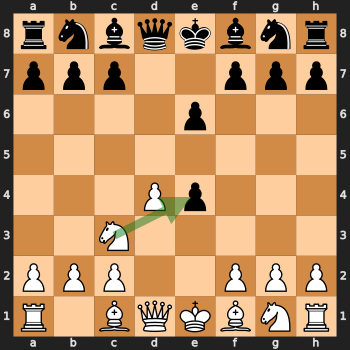

**Tarrasch – Mieses** (Berlin, 1916.??.??) — **White plays Nxe4** — Engine best

**FEN:** `rnbqkbnr/ppp2ppp/4p3/8/3Pp3/2N5/PPP2PPP/R1BQKBNR w KQkq - 0 4`

### Annotation
> Now White has a beautifully centralized knight, pressure on e5 and c5, and a superior pawn position (a pawn at d4 to one at e6) which assures him greater freedom of action.

### Engine (depth 22)
1. **Nxe4** (eval +0.44): Nxe4 Nd7 Nf3 Ngf6 Nxf6+ Nxf6 c3 a6 <- played
2. **a3** (eval -0.41): a3 Nf6 Bg5 Be7 Nge2 Nbd7 Ng3 Nb6
3. **Nge2** (eval -0.42): Nge2 f5 Be3 Nc6 f3 exf3 gxf3 Qh4+

### Template
```
{
  "include": true,
  "quality": "good",
  "reasoning": [
    "Nxe4 places White's knight on the centralized e4-square.",
    "After Nxe4, the knight exerts pressure on the e5- and c5-squares.",
    "After Nxe4, White has a pawn on d4 against Black's pawn on e6, giving White the superior pawn position and greater freedom of action."
  ],
  "book_commentary": "Now White has a beautifully centralized knight, pressure on e5 and c5, and a superior pawn position (a pawn at d4 to one at e6) which assures him greater freedom of action."
}
```

---


[3/12] Tarrasch – Mieses — bxc6 (middlegame)
  [INCLUDED] quality=good, wp_loss=0.0%


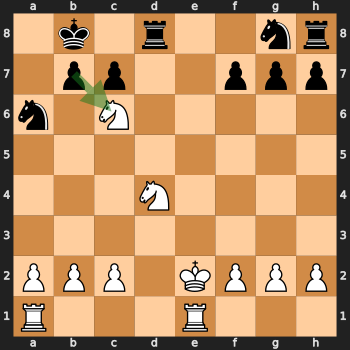

**Tarrasch – Mieses** (Gothenberg, 1920.??.??) — **Black plays bxc6** — Engine best

**FEN:** `1k1r2nr/1pp2ppp/n1N5/8/3N4/8/PPP1KPPP/R3R3 b - - 2 15`

### Annotation
> Black has no choice, as 15... Kc8 instead loses rook and pawn for the knight.

### Engine (depth 22)
1. **bxc6** (eval +1.50): bxc6 Nxc6+ Kc8 Nxd8 Kxd8 Rad1+ Kc8 Kf1 <- played
2. **Kc8** (eval +5.50): Kc8 Nxd8 Kxd8 Rad1 Kc8 Nf5 g6 Kf1
3. **Ka8** (eval +5.77): Ka8 Nxd8 Nh6 Nxf7 Nxf7 Kf1 Nd6 Rad1

### Template
```
{
  "include": true,
  "quality": "good",
  "reasoning": [
    "Black has no choice but to play bxc6.",
    "After 15...Kc8, White wins rook and pawn for the knight."
  ],
  "alternative": {
    "move": "Kc8",
    "reasoning": [
      "After 15...Kc8, Black loses rook and pawn for the knight."
    ]
  },
  "book_commentary": "Black has no choice, as 15... Kc8 instead loses rook and pawn for the knight."
}
```

---


[4/12] Capablanca – Villegas — Qxd7 (middlegame)
  [EXCLUDED: commentary analyzes the rejected alternative 18...dxe3 rather than explaining the played move 18...Qxd7] quality=good, wp_loss=0.0%


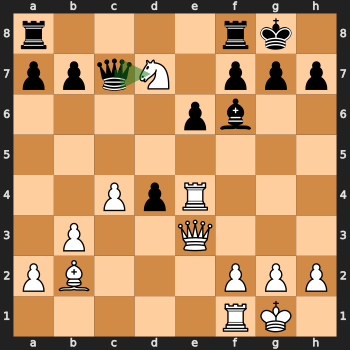

**Capablanca – Villegas** (Buenos Aires, 1914.??.??) — **Black plays Qxd7** — Engine best

**FEN:** `r4rk1/ppqN1ppp/4pb2/8/2PpR3/1P2Q3/PB3PPP/5RK1 b - - 0 18`

### Annotation
> If he accepts the offer and plays 18...dxe3 White reveals this combination:... Nxf6+ Kh8 (or 19...gxf6 20 Rg4+ Kh8 21 Bxf6#) 20 Rh4 (threatening 21 Rxh7#) 20... h6 21 Rxh6+! gxh6 22 Nd5+ Kg8 23 Nxc7 and White, with two pieces for a rook, wins easily.

### Engine (depth 22)
1. **Qxd7** (eval +0.52): Qxd7 Bxd4 Bxd4 Rxd4 Qe7 Rfd1 Rad8 g3 <- played
2. **dxe3** (eval +2.12): dxe3 Nxf6+ Kh8 Rh4 h6 Rxh6+ gxh6 Ne8+
3. **Kh8** (eval +4.38): Kh8 Bxd4 Qxd7 Bxf6 gxf6 Qh6 f5 Qf6+

### Template
```
{
  "include": false,
  "exclude_reason": "commentary analyzes the rejected alternative 18...dxe3 rather than explaining the played move 18...Qxd7",
  "book_commentary": "If he accepts the offer and plays 18...dxe3 White reveals this combination:... Nxf6+ Kh8 (or 19...gxf6 20 Rg4+ Kh8 21 Bxf6#) 20 Rh4 (threatening 21 Rxh7#) 20... h6 21 Rxh6+! gxh6 22 Nd5+ Kg8 23 Nxc7 and White, with two pieces for a rook, wins easily."
}
```

---


[5/12] Canal – Capablanca — Ra5 (endgame)
  [EXCLUDED: too minimal to extract meaningful move-specific reasoning] quality=good, wp_loss=0.5%


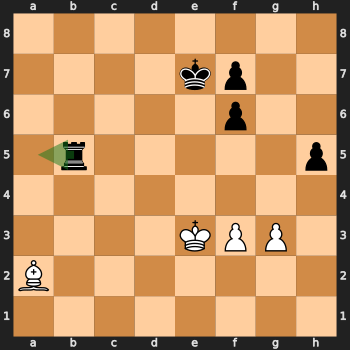

**Canal – Capablanca** (Budapest, 1929.??.??) — **Black plays Ra5** — Not engine best (best: Rc5, wp_loss: 0.5%)

**FEN:** `8/4kp2/5p2/1r5p/8/4KPP1/B7/8 b - - 5 48`

### Annotation
> Allowing the bishop one square on the a2-g8 diagonal.

### Engine (depth 22)
1. **Rc5** (eval -4.42): Rc5 Kf4 Rb5 Ke3 f5 f4 Ra5 Bc4
2. **Ra5** (eval -4.33): Ra5 Bc4 f5 f4 Ra3+ Kf2 h4 gxh4 <- played
3. **f5** (eval -4.25): f5 f4 Ra5 Bc4 Ra3+ Kf2 h4 gxh4

### Template
```
{
  "include": false,
  "exclude_reason": "too minimal to extract meaningful move-specific reasoning",
  "book_commentary": "Allowing the bishop one square on the a2-g8 diagonal."
}
```

---


[6/12] Noteboom – Doesburgh — Kf8 (endgame)
  [EXCLUDED: commentary analyzes 28...Kf7 rather than the played move 28...Kf8] quality=good, wp_loss=8.0%


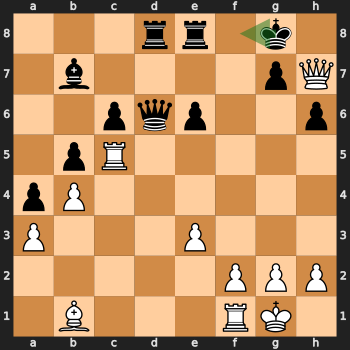

**Noteboom – Doesburgh** (Holland, 1931.??.??) — **Black plays Kf8** — Not engine best (best: Kf7, wp_loss: 8.0%)

**FEN:** `3rr1k1/1b4pQ/2pqp2p/1pR5/pP6/P3P3/5PPP/1B3RK1 b - - 5 28`

### Annotation
> On 28... Kf7 White can either win the exchange by a bishop check or pursue the attack by 29 f4, when the continuation might be 29... Rh8 30 Qg6+ Kf8 31 f5 e5 (or 31... Qe7 32 f6) 32 f6 and White wins.

### Engine (depth 22)
1. **Kf7** (eval +4.67): Kf7 Bg6+ Kf6 Bxe8 Rxe8 f4 Bc8 Qc2
2. **Kf8** (eval +6.94): Kf8 Bg6 Qd7 Rh5 Rc8 Rh4 Ke7 Bxe8 <- played

### Template
```
{
  "include": false,
  "exclude_reason": "commentary analyzes 28...Kf7 rather than the played move 28...Kf8",
  "book_commentary": "On 28... Kf7 White can either win the exchange by a bishop check or pursue the attack by 29 f4, when the continuation might be 29... Rh8 30 Qg6+ Kf8 31 f5 e5 (or 31... Qe7 32 f6) 32 f6 and White wins."
}
```

---


[7/12] Przepiorka – Prokes — Bh6+ (middlegame)
  [EXCLUDED: Commentary gives no move-specific explanation beyond resignation.] quality=good, wp_loss=0.0%


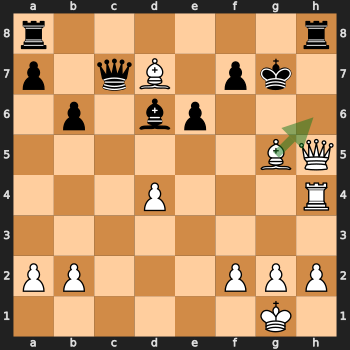

**Przepiorka – Prokes** (Budapest, 1929.??.??) — **White plays Bh6+** — Engine best

**FEN:** `r6r/p1qB1pk1/1p1bp3/6BQ/3P3R/8/PP3PPP/6K1 w - - 1 24`

### Annotation
> Black resigns.

### Engine (depth 22)
1. **Bh6+** (eval M3): Bh6+ Rxh6 Qxh6+ Kg8 Qh8# <- played
2. **Qg4** (eval +1.89): Qg4 Rxh4 Qxh4 Kg8 g3 Qc2 Bf6 Qh7
3. **Qf3** (eval -3.70): Qf3 Rxh4 Bf6+ Kg6 g3 Rg8 Bxh4 Qxd7

### Template
```
{
  "include": false,
  "exclude_reason": "Commentary gives no move-specific explanation beyond resignation.",
  "book_commentary": "Black resigns."
}
```

---


[8/12] Marshall – Tarrasch — g6+ (endgame)
  [EXCLUDED: Commentary only gives a trap line and does not explain the move g6+ itself beyond that variation.] quality=good, wp_loss=0.0%


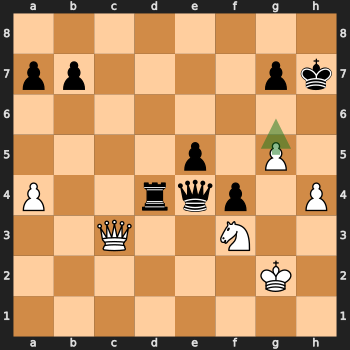

**Marshall – Tarrasch** (Nuremberg, 1905.??.??) — **White plays g6+** — Engine best

**FEN:** `8/pp4pk/8/4p1P1/P2rqp1P/2Q2N2/6K1/8 w - - 0 43`

### Annotation
> This is one of the traps: if Black plays 43... Kxg6, White replies 44 Qb3 (apparently trying to get a perpetual check) 44... Rd3, and now instead of 45 Qe6+ White plays 45 Qxd3 Qxd3 46 Nxe5+ followed by 47 Nxd3 regaining the queen and winning a rook.

### Engine (depth 22)
1. **g6+** (eval -7.37): g6+ Kh6 Qe1 Qxe1 Nxe1 e4 Kh3 Kxg6 <- played
2. **Qe1** (eval -7.71): Qe1 Qxe1 Nxe1 e4 Kh3 f3 Kg3 Rd1
3. **h5** (eval -7.91): h5 Qe2+ Kh3 Rd3 Qxd3+ Qxd3 Kg4 Qe2

### Template
```
{
  "include": false,
  "exclude_reason": "Commentary only gives a trap line and does not explain the move g6+ itself beyond that variation.",
  "book_commentary": "This is one of the traps: if Black plays 43... Kxg6, White replies 44 Qb3 (apparently trying to get a perpetual check) 44... Rd3, and now instead of 45 Qe6+ White plays 45 Qxd3 Qxd3 46 Nxe5+ followed by 47 Nxd3 regaining the queen and winning a rook."
}
```

---


[9/12] Spielmann – Wahle — e4 (opening)
  [INCLUDED] quality=good, wp_loss=0.0%


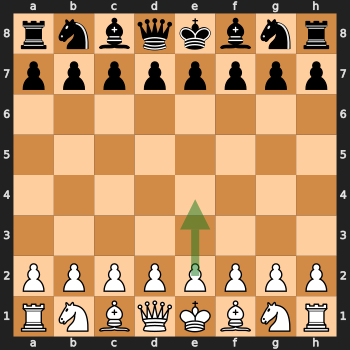

**Spielmann – Wahle** (Vienna, 1926.??.??) — **White plays e4** — Engine best

**FEN:** `rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1`

### Annotation
> This move accomplishes a great deal:
A pawn is fixed in the centre of the board.
The pawn exerts a grip on d5 and f5, and keeps Black’s pieces from settling on those squares.
White’s queen and bishop immediately have breathing space.

### Engine (depth 22)
1. **e4** (eval +0.39): e4 e5 Nf3 Nc6 Bb5 a6 Ba4 Nf6 <- played
2. **d4** (eval +0.26): d4 Nf6 c4 e6 Nc3 Bb4 Bd2 Bxc3
3. **Nf3** (eval +0.20): Nf3 d5 d4 Nf6 c4 e6 Bg5 Bb4+

### Template
```
{
  "include": true,
  "quality": "good",
  "reasoning": [
    "e4 places a pawn in the center.",
    "The pawn on e4 controls d5 and f5, preventing Black's pieces from settling on those squares.",
    "e4 opens lines for White's queen and king's bishop."
  ],
  "book_commentary": "This move accomplishes a great deal:\nA pawn is fixed in the centre of the board.\nThe pawn exerts a grip on d5 and f5, and keeps Black\u2019s pieces from settling on those squares.\nWhite\u2019s queen and bishop immediately have breathing space."
}
```

---


[10/12] Tarrasch – Mieses — Rde3 (middlegame)
  [INCLUDED] quality=good, wp_loss=2.0%


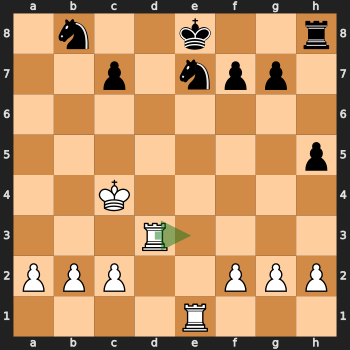

**Tarrasch – Mieses** (Gothenberg, 1920.??.??) — **White plays Rde3** — Not engine best (best: b4, wp_loss: 2.0%)

**FEN:** `1n2k2r/2p1npp1/8/7p/2K5/3R4/PPP2PPP/4R3 w - - 2 22`

### Annotation
> Doubles the pressure and threatens to capture the knight.

### Engine (depth 22)
1. **b4** (eval +3.38): b4 f6 Red1 Nec6 f4 Kf7 a4 Re8
2. **a4** (eval +3.03): a4 Rh6 Rde3 Rc6+ Kb3 Rb6+ Ka3 Nc6
3. **Ra3** (eval +2.90): Ra3 f6 b4 Kf7 Ra7 Rc8 Ra8 Nec6

*Played: **Rde3** (+3.07): Rde3 Nc6 b4 f6 f4 Kf7 Rd3 Ra8* <- played

### Template
```
{
  "include": true,
  "quality": "good",
  "reasoning": [
    "Rde3 doubles the rooks on the e-file.",
    "Rde3 threatens to capture the knight on e7."
  ],
  "book_commentary": "Doubles the pressure and threatens to capture the knight."
}
```

---


[11/12] Capablanca – Villegas — e3 (opening)
  [INCLUDED] quality=good, wp_loss=1.6%


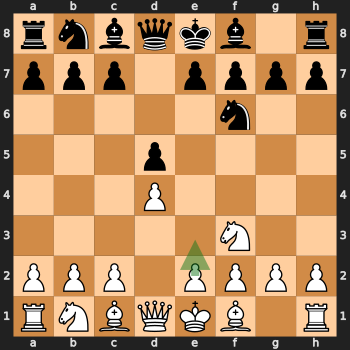

**Capablanca – Villegas** (Buenos Aires, 1914.??.??) — **White plays e3** — Not engine best (best: c4, wp_loss: 1.6%)

**FEN:** `rnbqkb1r/ppp1pppp/5n2/3p4/3P4/5N2/PPP1PPPP/RNBQKB1R w KQkq - 2 3`

### Annotation
> Not the most energetic procedure, but White need not be aggressive from the start. The opening itself is so strong that White can build up a promising position merely by developing his pieces so that they occupy the most suitable squares immediately. The method is simplicity itself:
Put every single piece to work, and move no piece twice until development is complete.
The fact that 3 e3 releases one bishop but shuts in another is of little moment, as the c1-bishop can get into the game by way of b2. White does not indicate his specific intentions: he might play the Colle Attack or perhaps simply develop the bishop at d3 with a view to early kingside castling.

### Engine (depth 22)
1. **c4** (eval +0.29): c4 e6 g3 c5 cxd5 exd5 Bg2 Nc6
2. **Bf4** (eval +0.17): Bf4 c5 e3 Nc6 c3 Nh5 dxc5 Nxf4
3. **e3** (eval +0.12): e3 e6 Bd3 c5 b3 Be7 Bb2 O-O <- played

### Template
```
{
  "include": true,
  "quality": "good",
  "reasoning": [
    "e3 is a quiet developing move rather than the most energetic continuation.",
    "e3 opens a line for one bishop while temporarily shutting in the bishop on c1.",
    "After e3, the bishop on c1 can still enter the game by way of b2.",
    "After e3, White keeps his plans flexible: he may choose a Colle setup or develop the bishop to d3 and castle kingside early."
  ],
  "book_commentary": "Not the most energetic procedure, but White need not be aggressive from the start. The opening itself is so strong that White can build up a promising position merely by developing his pieces so that they occupy the most suitable squares immediately. The method is simplicity itself:\nPut every single piece to work, and move no piece twice until development is complete.\nThe fact that 3 e3 releases one bishop but shuts in another is of little moment, as the c1-bishop can get into the game by way of b2. White does not indicate his specific intentions: he might play the Colle Attack or perhaps simply develop the bishop at d3 with a view to early kingside castling."
}
```

---


[12/12] Rubinstein – Maroczy — gxh6 (endgame)
  [INCLUDED] quality=good, wp_loss=0.0%


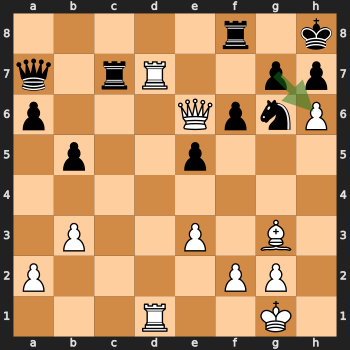

**Rubinstein – Maroczy** (Gothenberg, 1920.??.??) — **Black plays gxh6** — Engine best

**FEN:** `5r1k/q1rR2pp/p3QpnP/1p2p3/8/1P2P1B1/P4PP1/3R2K1 b - - 4 34`

### Annotation
> 34... Rxd7 is no better since the recapture 35 Rxd7 threatens mate on one side, and the queen on the other. White also forces mate after 34... Rg8 35 hxg7+ Rxg7 36 Rd8+.

### Engine (depth 22)
1. **gxh6** (eval +4.78): gxh6 Bh4 Rxd7 Rxd7 Qxd7 Qxd7 Nxh4 Qb7 <- played
2. **Rxd7** (eval +6.14): Rxd7 Rxd7 Qxd7 Qxd7 gxh6 f4 Kg8 f5
3. **Rg8** (eval M4): Rg8 hxg7+ Rxg7 Rd8+ Nf8 Rxf8+ Rg8 Rxg8#

### Template
```
{
  "include": true,
  "quality": "good",
  "reasoning": [
    "34...Rxd7 is no better because after 34...Rxd7 35.Rxd7, White threatens both mate and the black queen.",
    "White also forces mate after 34...Rg8 35.hxg7+ Rxg7 36.Rd8+."
  ],
  "variation": "34...Rg8 35.hxg7+ Rxg7 36.Rd8+",
  "alternative": {
    "move": "Rxd7",
    "reasoning": [
      "After 34...Rxd7 35.Rxd7, White threatens mate on one side and the queen on the other."
    ],
    "variation": "34...Rxd7 35.Rxd7"
  },
  "book_commentary": "34... Rxd7 is no better since the recapture 35 Rxd7 threatens mate on one side, and the queen on the other. White also forces mate after 34... Rg8 35 hxg7+ Rxg7 36 Rd8+."
}
```

---


Done. 12 templates: 6 included, 6 excluded


In [32]:
results = []
for i, c in enumerate(candidates):
    e = c['entry']
    board = chess.Board(e['fen'])
    san = board.san(chess.Move.from_uci(e['move_uci']))
    game = e['metadata'].get('White', '?') + ' – ' + e['metadata'].get('Black', '?')

    print(f"\n{'='*60}")
    print(f"[{i+1}/{len(candidates)}] {game} — {san} ({c['phase']})")
    print(f"{'='*60}")

    engine_lines = get_engine_analysis(e['fen'], e['move_uci'])

    # Compute wp_loss on the fly from engine lines
    wp, best_san, is_top = compute_wp_loss(engine_lines, e['move_uci'], board.turn)
    e['wp_loss'] = wp
    e['best_move_san'] = best_san
    e['is_top_engine_move'] = is_top

    quality = 'blunder' if wp > 30 else 'mistake' if wp > 20 else 'inaccuracy' if wp > 10 else 'good'

    generated_text, tool_log = generate_with_tools(e, engine_lines)
    parsed = parse_json_output(generated_text)

    pp_include, pp_reason = postprocess_filter(e, parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason
        print(f"  ** POST-FILTER: excluded — {pp_reason}")

    results.append({
        'entry': e, 'quality': quality, 'phase': c['phase'],
        'engine_lines': engine_lines, 'generated': generated_text,
        'parsed': parsed, 'tool_log': tool_log,
    })

    is_bad = quality in ('inaccuracy', 'mistake', 'blunder')
    tag = "INCLUDED" if parsed.get('include', True) else f"EXCLUDED: {parsed.get('exclude_reason', '?')}"
    print(f"  [{tag}] quality={quality}, wp_loss={wp:.1f}%")
    show_example(e, engine_lines, json.dumps(parsed, indent=2), is_bad_move=is_bad)

included = sum(1 for r in results if r['parsed'].get('include', True))
excluded = len(results) - included
print(f"\nDone. {len(results)} templates: {included} included, {excluded} excluded")

---
### Save Results

In [ ]:
included_path = os.path.join(DATA_DIR, 'generated_templates.jsonl')
excluded_path = os.path.join(DATA_DIR, 'generated_templates_excluded.jsonl')

def build_row(r):
    return {
        'fen': r['entry']['fen'],
        'move_uci': r['entry']['move_uci'],
        'move_san': chess.Board(r['entry']['fen']).san(
            chess.Move.from_uci(r['entry']['move_uci'])),
        'annotation': r['entry']['annotation'],
        'wp_loss': r['entry'].get('wp_loss', 0),
        'phase': r['phase'],
        'extracted': r['parsed'],
        'engine_lines': r['engine_lines'],
        'tool_log': r.get('tool_log', []),
        'model': MODEL,
        'provider': PROVIDER,
        'game': (r['entry']['metadata'].get('White', '?') + ' \u2013 ' +
                 r['entry']['metadata'].get('Black', '?')),
    }

inc_rows = [r for r in results if r['parsed'].get('include', True)]
exc_rows = [r for r in results if not r['parsed'].get('include', True)]

with open(included_path, 'w') as f:
    for r in inc_rows:
        f.write(json.dumps(build_row(r)) + '\n')

with open(excluded_path, 'w') as f:
    for r in exc_rows:
        f.write(json.dumps(build_row(r)) + '\n')

print(f"Included: {len(inc_rows)} -> {included_path}")
print(f"Excluded: {len(exc_rows)} -> {excluded_path}")

---
### Batch Generation

Generate gold extractions for all positions. Append-safe (skips already-done positions).

In [ ]:
SEED = 42
START = 1      # 1-indexed start
END = None     # None = all entries
OUTPUT_PATH = os.path.join(DATA_DIR, 'gold_extractions.jsonl')

_all_entries = [e for e in DATASET if e['fen'] not in DEMO_FENS]
_batch_order = list(range(len(_all_entries)))
random.Random(SEED).shuffle(_batch_order)

_end = END if END is not None else len(_all_entries)

# Skip already-generated positions
_already_done = set()
if os.path.exists(OUTPUT_PATH):
    with open(OUTPUT_PATH) as f:
        for line in f:
            row = json.loads(line)
            _already_done.add(row['position_number'])
    print(f"Resuming: {len(_already_done)} already generated")

print(f"Range: positions {START}..{_end} ({_end - START + 1} total)")

n_generated = 0
n_skipped = 0

for idx in range(START - 1, _end):
    pos_num = idx + 1
    if pos_num in _already_done:
        n_skipped += 1
        continue

    entry = _all_entries[_batch_order[idx]]
    board = chess.Board(entry['fen'])
    move_san = board.san(chess.Move.from_uci(entry['move_uci']))
    game = entry['metadata'].get('White', '?') + ' – ' + entry['metadata'].get('Black', '?')

    # Compute wp_loss on the fly from engine lines
    engine_lines = get_engine_analysis(entry['fen'], entry['move_uci'])
    wp, best_san, is_top = compute_wp_loss(engine_lines, entry['move_uci'], board.turn)
    entry['wp_loss'] = wp
    entry['best_move_san'] = best_san
    entry['is_top_engine_move'] = is_top

    quality = 'blunder' if wp > 30 else 'mistake' if wp > 20 else 'inaccuracy' if wp > 10 else 'good'

    print(f"[{pos_num}/{_end}] {game} — {move_san} ({quality}, wp_loss={wp:.1f}%)")

    generated_text, tool_log = generate_with_tools(entry, engine_lines)
    parsed = parse_json_output(generated_text)

    pp_include, pp_reason = postprocess_filter(entry, parsed)
    if not pp_include and parsed.get('include', True):
        parsed['include'] = False
        parsed['exclude_reason'] = pp_reason
        print(f"  ** POST-FILTER: excluded — {pp_reason}")

    row = {
        'position_number': pos_num,
        'fen': entry['fen'], 'move_uci': entry['move_uci'], 'move_san': move_san,
        'annotation': entry['annotation'], 'wp_loss': wp, 'quality': quality,
        'game': game, 'engine_lines': engine_lines, 'extracted': parsed,
        'tool_log': tool_log, 'model': MODEL, 'provider': PROVIDER,
    }

    with open(OUTPUT_PATH, 'a') as f:
        f.write(json.dumps(row) + '\n')

    inc_tag = "INCL" if parsed.get('include', True) else "EXCL"
    print(f"  [{inc_tag}] {len(parsed.get('reasoning', []))} atoms, {len(tool_log)} tool calls")
    n_generated += 1

print(f"\nDone. {n_generated} generated, {n_skipped} skipped.")
print(f"Output: {OUTPUT_PATH}")